# Zadanie 1: Implementacja i trenowanie modelu CNN dla zestawu danych CIFAR-100


Twoim zadaniem jest uzupełnienie brakujących fragmentów kodu w podanym szablonie, aby stworzyć działający model konwolucyjnej sieci neuronowej (CNN) do klasyfikacji obrazów z zestawu danych CIFAR-100. Poniżej znajdziesz opis zadania oraz wskazówki dotyczące brakujących miejsc w kodzie.

## Cel zadania
- Zaimplementować model CNN do rozpoznawania 100 klas obrazów z CIFAR-100.
- Uzupełnić brakujące fragmenty kodu w sekcjach modelu, treningu, walidacji i wizualizacji.
- Przeprowadzić trening z wczesnym zatrzymaniem (early stopping) i walidacją krzyżową.
- Zwizualizować wyniki treningu i predykcje modelu.

## Zestaw danych
- **CIFAR-100**: Zawiera 60 000 kolorowych obrazów (32x32 piksele) podzielonych na 100 klas (np. jabłko, rower, tygrys).
- Dane są podzielone na zestaw treningowy (50 000 obrazów) i testowy (10 000 obrazów).
- W kodzie użyto 20% danych treningowych jako zestaw walidacyjny.

## Instrukcje
Poniżej znajduje się szablon kodu z brakującymi fragmentami oznaczonymi jako `###`. Twoim zadaniem jest uzupełnienie tych fragmentów. Kod jest napisany w Pythonie z użyciem bibliotek PyTorch, torchvision, NumPy, matplotlib i scikit-learn.

### Kod do uzupełnienia

```python
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Lista klas CIFAR-100
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 1. Przygotowanie danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Podział na zestaw treningowy i walidacyjny
val_size = ###  # Uzupełnij: Jaka część danych treningowych powinna być użyta do walidacji?
num_train = len(trainset)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(val_size * num_train))
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

trainloader = DataLoader(trainset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(trainset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# 2. Definicja modelu
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        ### Uzupełnij: Zdefiniuj warstwy sieci (np. konwolucyjne, pooling, w pełni połączone)
    
    def forward(self, x):
        ### Uzupełnij: Zdefiniuj przepływ danych przez warstwy (forward pass)
        return x

# 3. Funkcja trenująca
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        # Pętla treningowa
        model.train()
        train_loss = 0.0
        ### Uzupełnij: Zaimplementuj pętlę treningową (przebieg do przodu, obliczanie straty, aktualizacja wag)
        
        # Pętla walidacyjna
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        ### Uzupełnij: Zaimplementuj pętlę walidacyjną (obliczanie straty i dokładności)
        
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")
        
        # Wczesne zatrzymanie
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                model.load_state_dict(best_model)
                break
    
    return train_losses, val_losses, val_accuracies

# 4. Funkcje wizualizacyjne
def plot_metrics(train_losses, val_losses, val_accuracies):
    ### Uzupełnij: Zaimplementuj wykresy dla strat treningowych, walidacyjnych i dokładności walidacyjnej

def visualize_predictions(model, testloader, num_images=5):
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu().numpy()
    images = images * 0.5 + 0.5  # Denormalizacja
    images = np.transpose(images, (0, 2, 3, 1))
    
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        plt.axis('off')
    plt.show()

# 5. Walidacja krzyżowa
def cross_validation(k_folds=5, num_epochs=5):
    kfold = KFold(n_splits=k_folds, shuffle=True)
    results = []
    ### Uzupełnij: Zaimplementuj walidację krzyżową, trenując model dla każdego podziału i obliczając średnią dokładność
    
    print(f'Average Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# 6. Główny kod
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trening z wczesnym zatrzymaniem
train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=10, patience=3)

# Wizualizacja
plot_metrics(train_losses, val_losses, val_accuracies)
visualize_predictions(model, testloader)

# Opcjonalna walidacja krzyżowa
cross_validation(k_folds=5, num_epochs=5)

# 7. Końcowa ewaluacja na zestawie testowym
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")
```

## Wskazówki do uzupełnienia kodu

1. **Sekcja 1: Przygotowanie danych**
   - Ustaw `val_size` na wartość określającą, jaka część danych treningowych będzie użyta do walidacji (np. 0.2 dla 20%).

2. **Sekcja 2: Definicja modelu**
   - W metodzie `__init__` zdefiniuj warstwy sieci (np. konwolucyjne `nn.Conv2d`, ReLU `nn.ReLU`, pooling `nn.MaxPool2d`, w pełni połączone `nn.Linear`).
   - W metodzie `forward` opisz, jak dane przepływają przez warstwy (np. konwolucja -> ReLU -> pooling -> spłaszczenie -> warstwy w pełni połączone).
   - Przykład: Obrazy CIFAR-100 mają rozmiar 32x32x3. Po dwóch warstwach pooling (2x2) rozmiar zmniejsza się do 8x8. Oblicz odpowiedni rozmiar dla warstwy `nn.Linear`.

3. **Sekcja 3: Funkcja trenująca**
   - W pętli treningowej:
     - Przenieś dane na urządzenie (`device`).
     - Wykonaj przebieg do przodu (`model(images)`).
     - Oblicz stratę (`criterion(outputs, labels)`).
     - Wykonaj wsteczną propagację (`loss.backward()`) i aktualizację wag (`optimizer.step()`).
   - W pętli walidacyjnej:
     - Oblicz stratę i dokładność (porównaj predykcje z etykietami).
     - Użyj `torch.no_grad()` dla wydajności.

4. **Sekcja 4: Funkcje wizualizacyjne**
   - W funkcji `plot_metrics` narysuj dwa wykresy:
     - Jeden dla strat treningowych i walidacyjnych w zależności od epoki.
     - Drugi dla dokładności walidacyjnej w zależności od epoki.
   - Użyj `matplotlib.pyplot` do tworzenia wykresów.

5. **Sekcja 5: Walidacja krzyżowa**
   - Utwórz pętle dla każdego podziału (`fold`) w `KFold`.
   - Dla każdego podziału stwórz nowe `DataLoader`y, nowy model, optimizer i criterion.
   - Trenuj model i zapisz najlepszą dokładność walidacyjną w liście `results`.

## Wymagania
- Uzupełnij wszystkie brakujące fragmenty kodu oznaczone `###`.
- Upewnij się, że kod działa bez błędów i poprawnie trenuje model.
- Model powinien osiągać rozsądną dokładność na zestawie testowym (np. >30% po 10 epokach).
- Wykresy w `plot_metrics` powinny być czytelne, z etykietami osi i legendą.
- Wyniki walidacji krzyżowej powinny pokazywać średnią dokładność i odchylenie standardowe.

## Dodatkowe wskazówki
- **Biblioteki:** Upewnij się, że masz zainstalowane `torch`, `torchvision`, `matplotlib`, `numpy`, `scikit-learn`.
- **Uruchomienie:** Kod można uruchomić w środowisku z Pythonem (np. Jupyter Notebook). GPU przyspieszy trening, ale CPU też wystarczy.
- **Debugowanie:** Sprawdzaj wymiary tensorów w metodzie `forward` (np. używając `print(x.shape)`).
- **Dokumentacja PyTorch:** Skorzystaj z dokumentacji, aby zrozumieć warstwy `nn.Conv2d`, `nn.MaxPool2d`, `nn.Linear` itp.

Powodzenia w realizacji zadania!

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [2]:
# Lista klas CIFAR-100
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 1. Przygotowanie danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Podział na zestaw treningowy i walidacyjny
val_size = 0.2
num_train = len(trainset)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(val_size * num_train))
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

trainloader = DataLoader(trainset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(trainset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Blok 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Blok 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3) # 30% szans na wyłączenie neuronu
        
        # Po dwóch poolingach obraz 32x32 -> 8x8
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        # Blok 1: Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> Pool
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        
        # Blok 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout(x)
        
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = model.to(device)
    
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        # --- PĘTLA TRENINGOWA ---
        model.train()
        running_train_loss = 0.0
        
        for images, labels in trainloader:
            # 1. Przeniesienie danych na urządzenie (GPU/CPU)
            images, labels = images.to(device), labels.to(device)
            
            # 2. Wyzerowanie gradientów z poprzedniego kroku
            optimizer.zero_grad()
            
            # 3. Forward pass: przewidywanie wyników
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 4. Backward pass: obliczenie gradientów
            loss.backward()
            
            # 5. Optymalizacja: aktualizacja wag
            optimizer.step()
            
            running_train_loss += loss.item()
        
        # Obliczanie średniej straty treningowej
        epoch_train_loss = running_train_loss / len(trainloader)
        train_losses.append(epoch_train_loss)

        # --- PĘTLA WALIDACYJNA ---
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        
        # Wyłączenie obliczania gradientów dla oszczędności pamięci i czasu
        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                # Obliczanie dokładności (Accuracy)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = running_val_loss / len(valloader)
        val_accuracy = 100 * correct / total
        
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}, Train Loss: {epoch_train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")
        
        # --- WCZESNE ZATRZYMANIE (EARLY STOPPING) ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict() # Zapisujemy najlepsze wagi
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs. Loading best model.")
                model.load_state_dict(best_model)
                break
    
    return train_losses, val_losses, val_accuracies

In [5]:
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # Wykres 1: Strata (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Strata treningowa')
    plt.plot(epochs, val_losses, 'ro-', label='Strata walidacyjna')
    plt.title('Strata treningowa i walidacyjna')
    plt.xlabel('Epoki')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Wykres 2: Dokładność (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'go-', label='Dokładność walidacyjna')
    plt.title('Dokładność walidacyjna w czasie')
    plt.xlabel('Epoki')
    plt.ylabel('Dokładność (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, testloader, num_images=5):
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu().numpy()
    images = images * 0.5 + 0.5  # Denormalizacja
    images = np.transpose(images, (0, 2, 3, 1))
    
    cols = 5
    rows = int(np.ceil(num_images / cols))
    
    plt.figure(figsize=(15, 3 * rows))
    
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(images[i], 0, 1))
        
        pred_idx = predicted[i].item()
        true_idx = labels[i].item()
        color = 'green' if pred_idx == true_idx else 'red'
        
        plt.title(f'P: {classes[pred_idx]}\nT: {classes[true_idx]}', color=color, fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [8]:
from torch.utils.data import DataLoader, Subset


def cross_validation(k_folds=5, num_epochs=5):
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Rozpoczynanie {k_folds}-krotnej walidacji krzyżowej...")

    for fold, (train_ids, val_ids) in enumerate(kfold.split(np.arange(len(trainset)))):
        print(f"\n--- FOLD {fold + 1} ---")
        
        # Przygotowanie loaderów dla tego folda
        trainloader_fold = DataLoader(Subset(trainset, train_ids), batch_size=64, shuffle=True)
        valloader_fold = DataLoader(Subset(trainset, val_ids), batch_size=64, shuffle=False)
        
        # Restart modelu (inicjalizacja wag od zera)
        model_fold = SimpleCNN().to(device)
        criterion_fold = nn.CrossEntropyLoss()
        optimizer_fold = optim.Adam(model_fold.parameters(), lr=0.001)
        
        # Trening (wywołujemy Twoją funkcję train_model)
        _, _, val_accuracies = train_model(
            model_fold, trainloader_fold, valloader_fold, 
            criterion_fold, optimizer_fold, num_epochs, patience=2
        )
        
        # Wybieramy najlepszą dokładność osiągniętą w tym konkretnym foldzie
        best_acc = max(val_accuracies)
        results.append(best_acc)
        print(f"Fold {fold + 1} Best Accuracy: {best_acc:.2f}%")

    # --- RAPORT KOŃCOWY ---
    mean_acc = np.mean(results)
    std_acc = np.std(results)
    
    print("\n" + "="*40)
    print(f"WYNIKI WALIDACJI KRZYŻOWEJ ({k_folds} FOLDÓW):")
    print(f"Poszczególne wyniki: {[round(r, 2) for r in results]}")
    print(f"Średnia dokładność: {mean_acc:.2f}%")
    print(f"Odchylenie standardowe: {std_acc:.2f}%")
    print(f"Przedział ufności: {mean_acc - std_acc:.2f}% - {mean_acc + std_acc:.2f}%")
    print("="*40)
    
    return results

Using device: cuda
Epoch 1, Train Loss: 4.051, Val Loss: 3.559, Val Accuracy: 14.23%
Epoch 2, Train Loss: 3.534, Val Loss: 3.179, Val Accuracy: 21.52%
Epoch 3, Train Loss: 3.247, Val Loss: 2.896, Val Accuracy: 26.61%
Epoch 4, Train Loss: 3.030, Val Loss: 2.708, Val Accuracy: 31.10%
Epoch 5, Train Loss: 2.829, Val Loss: 2.486, Val Accuracy: 34.57%
Epoch 6, Train Loss: 2.684, Val Loss: 2.392, Val Accuracy: 37.77%
Epoch 7, Train Loss: 2.573, Val Loss: 2.336, Val Accuracy: 38.11%
Epoch 8, Train Loss: 2.455, Val Loss: 2.220, Val Accuracy: 41.35%
Epoch 9, Train Loss: 2.363, Val Loss: 2.197, Val Accuracy: 41.93%
Epoch 10, Train Loss: 2.278, Val Loss: 2.089, Val Accuracy: 43.97%
Epoch 11, Train Loss: 2.191, Val Loss: 2.097, Val Accuracy: 44.60%
Epoch 12, Train Loss: 2.116, Val Loss: 1.995, Val Accuracy: 46.64%
Epoch 13, Train Loss: 2.048, Val Loss: 2.022, Val Accuracy: 45.70%
Epoch 14, Train Loss: 1.965, Val Loss: 1.960, Val Accuracy: 47.00%
Epoch 15, Train Loss: 1.912, Val Loss: 1.941, Val Ac

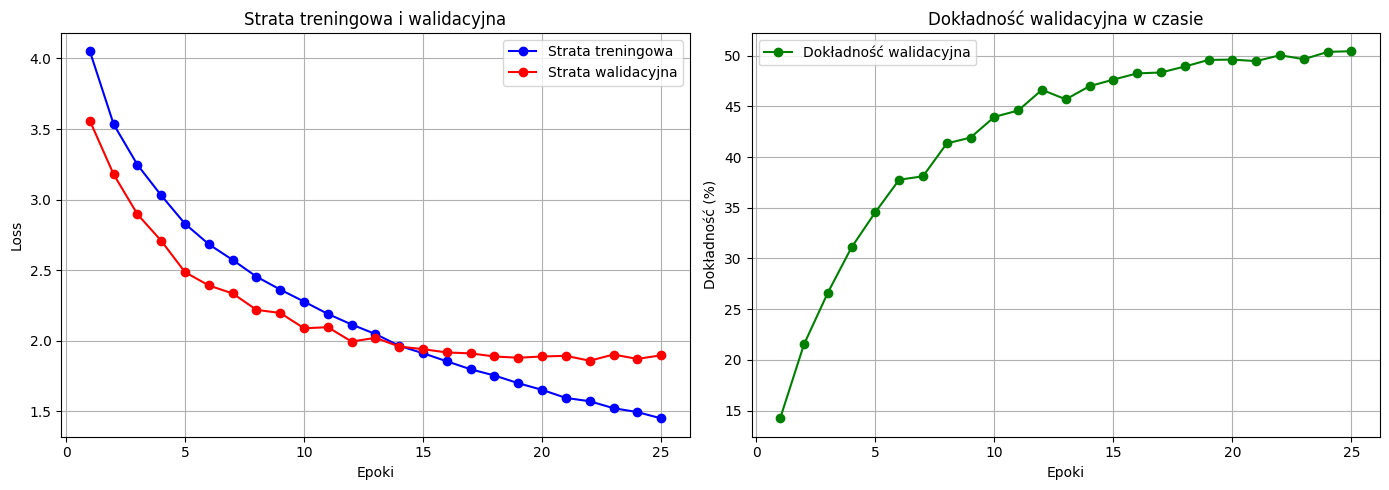

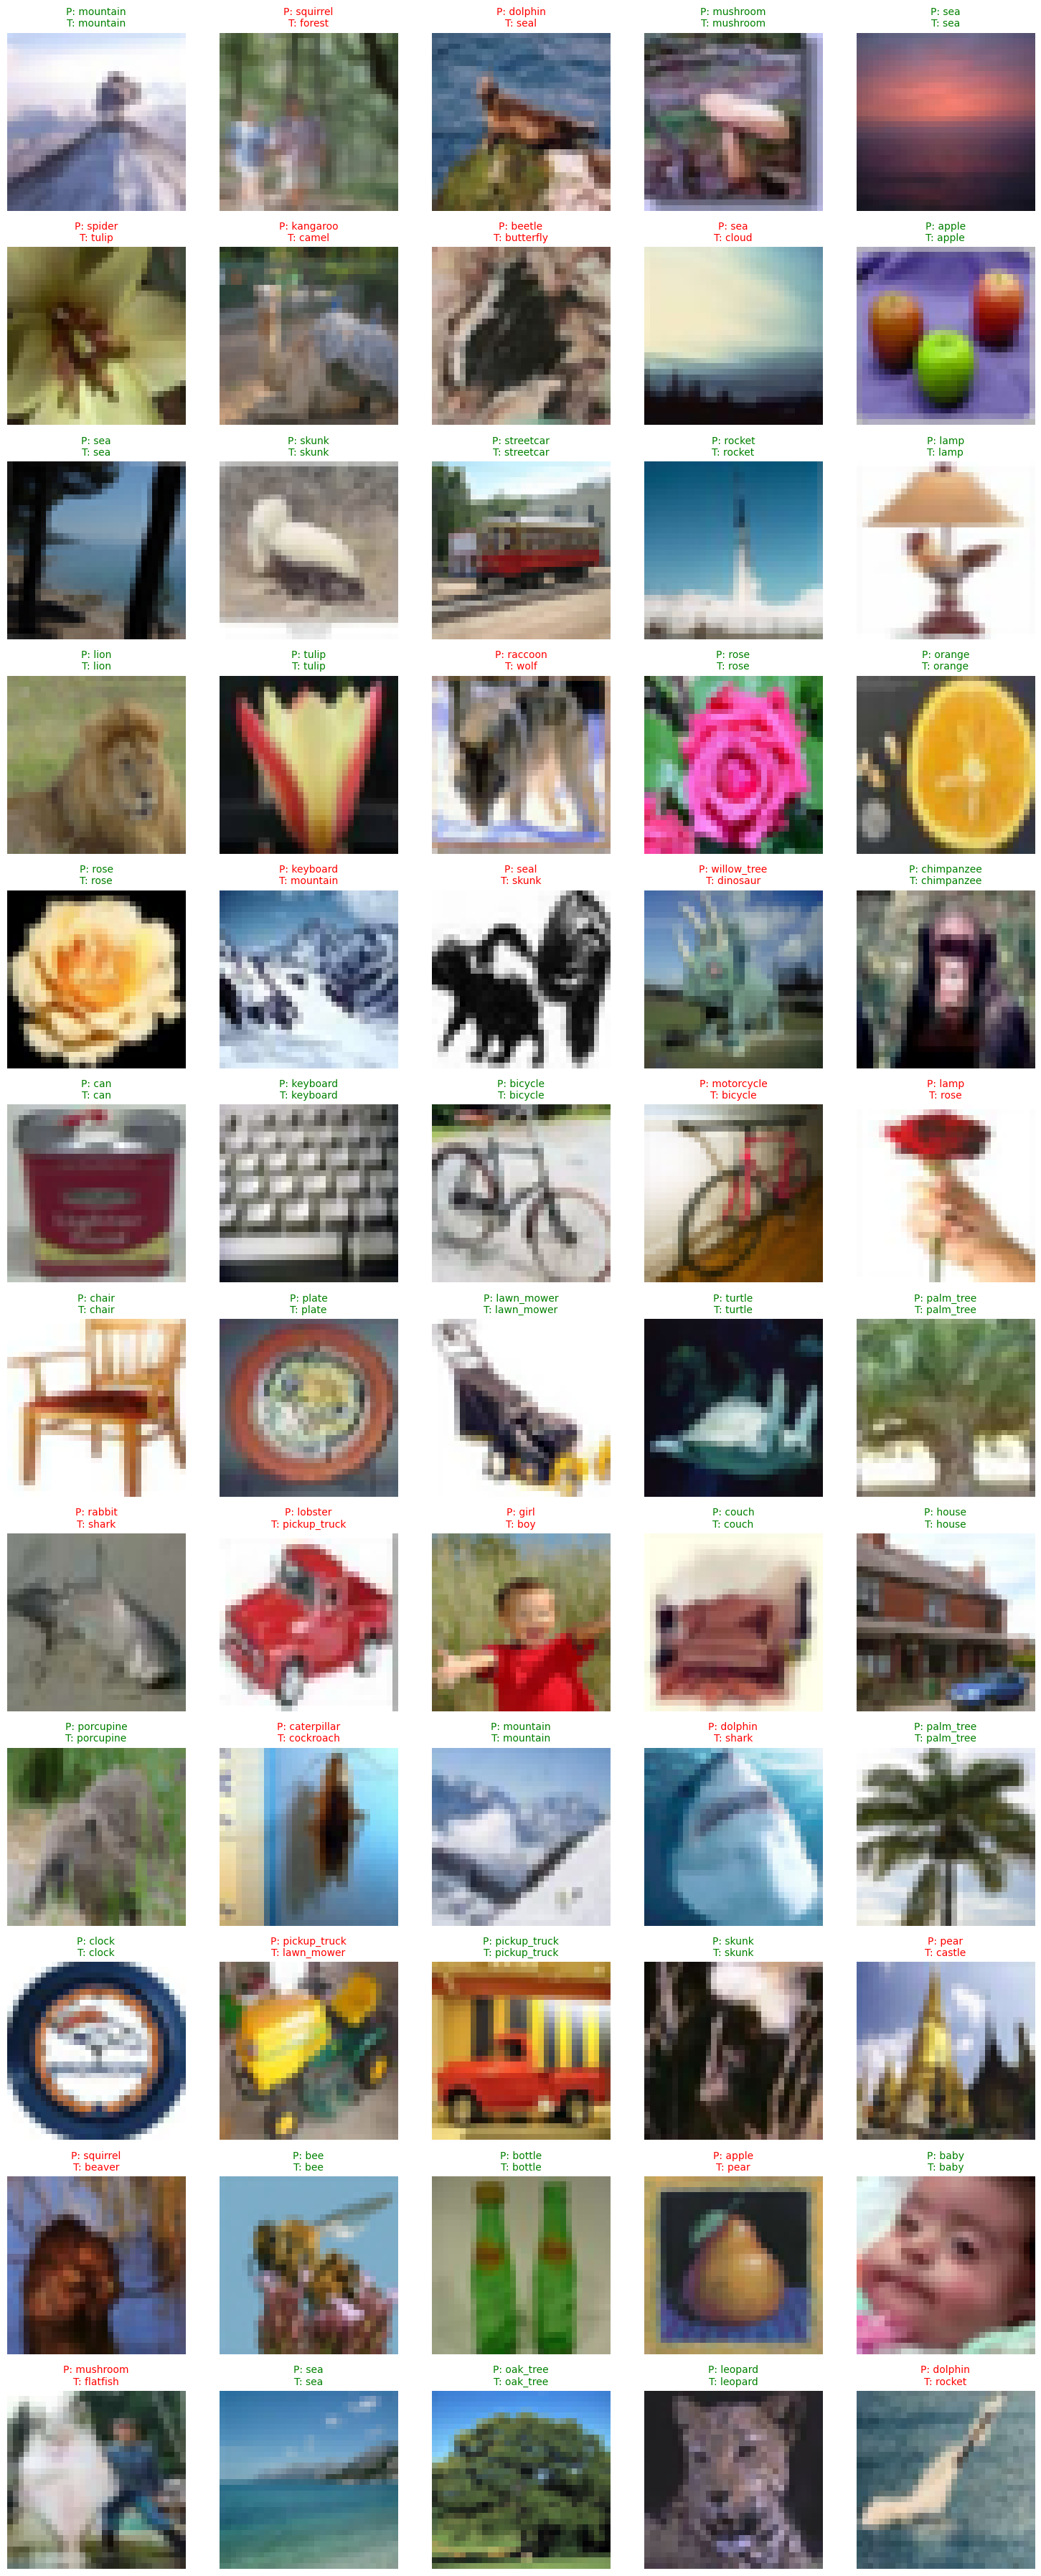

--- ROZPOCZĘCIE WALIDACJI KRZYŻOWEJ (5 FOLDÓW) ---

>> FOLD 1/5
Using device: cuda
Epoch 1, Train Loss: 4.115, Val Loss: 3.578, Val Accuracy: 14.30%
Epoch 2, Train Loss: 3.654, Val Loss: 3.367, Val Accuracy: 18.48%
Epoch 3, Train Loss: 3.406, Val Loss: 3.058, Val Accuracy: 23.78%
Epoch 4, Train Loss: 3.218, Val Loss: 2.842, Val Accuracy: 27.89%
Epoch 5, Train Loss: 3.064, Val Loss: 2.691, Val Accuracy: 31.07%
Epoch 6, Train Loss: 2.908, Val Loss: 2.557, Val Accuracy: 33.19%
Epoch 7, Train Loss: 2.798, Val Loss: 2.520, Val Accuracy: 34.63%
Epoch 8, Train Loss: 2.701, Val Loss: 2.377, Val Accuracy: 38.13%
Epoch 9, Train Loss: 2.621, Val Loss: 2.308, Val Accuracy: 38.97%
Epoch 10, Train Loss: 2.539, Val Loss: 2.337, Val Accuracy: 38.59%
Epoch 11, Train Loss: 2.467, Val Loss: 2.203, Val Accuracy: 41.43%
Epoch 12, Train Loss: 2.406, Val Loss: 2.196, Val Accuracy: 41.29%
Epoch 13, Train Loss: 2.346, Val Loss: 2.178, Val Accuracy: 41.68%
Epoch 14, Train Loss: 2.298, Val Loss: 2.145, Val Accur

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trening z wczesnym zatrzymaniem
train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=30, patience=3)

# Wizualizacja
plot_metrics(train_losses, val_losses, val_accuracies)
visualize_predictions(model, testloader, num_images=60)

# Opcjonalna walidacja krzyżowa
cross_validation(k_folds=5, num_epochs=15)

# 7. Końcowa ewaluacja na zestawie testowym
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

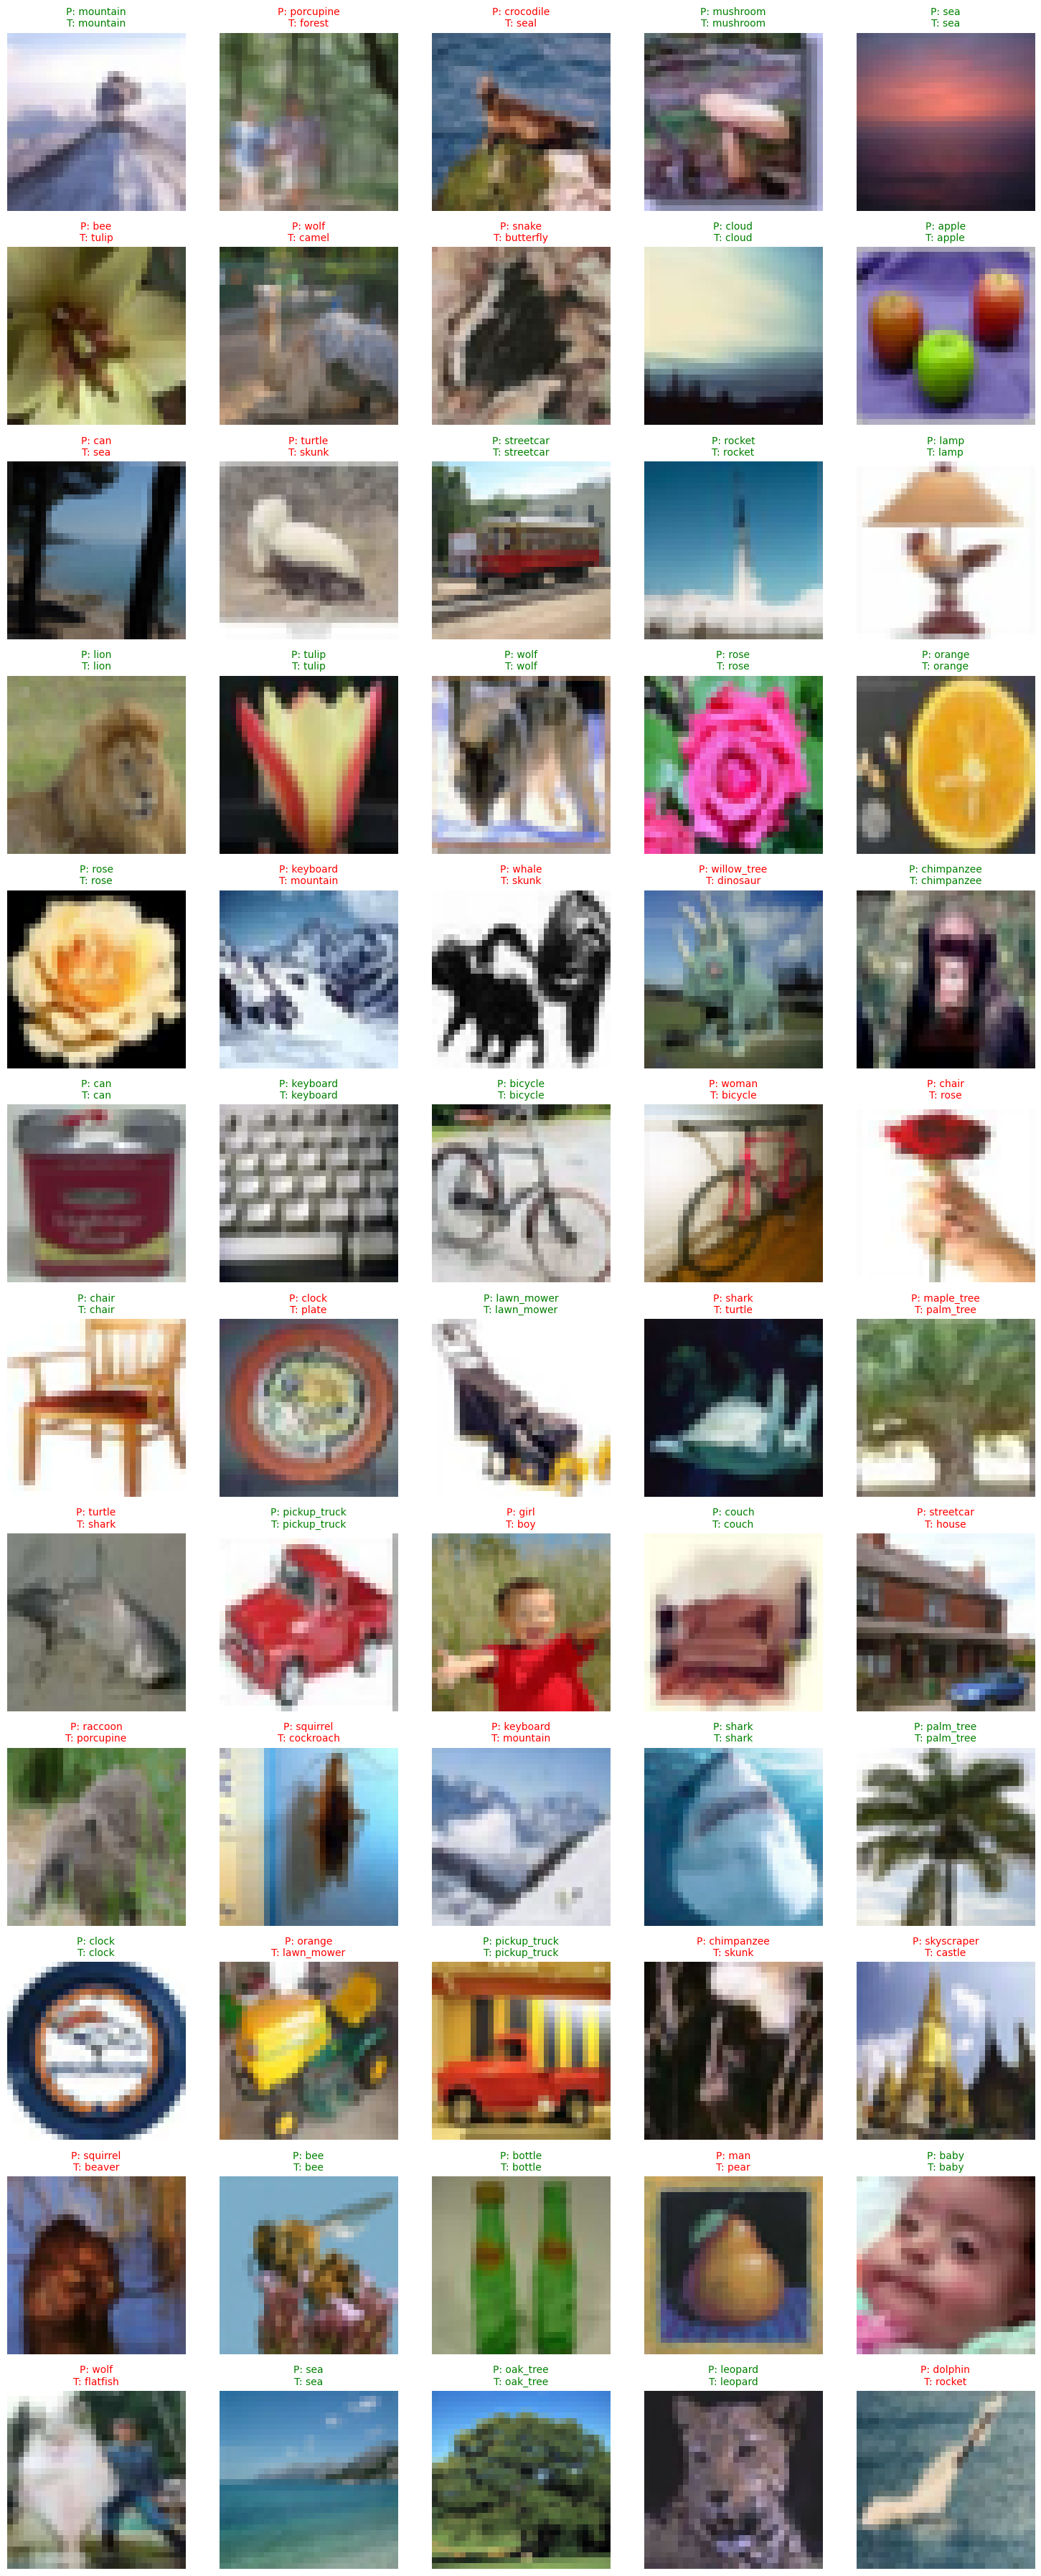

In [19]:
visualize_predictions(model, testloader, num_images=60)

# Zadanie 2: # Zadanie: Implementacja i trenowanie modelu PointNet dla zbioru danych ModelNet10


Twoim zadaniem jest uzupełnienie brakujących fragmentów kodu w podanym szablonie, aby stworzyć działający model PointNet do klasyfikacji chmur punktów z zestawu danych ModelNet10. Poniżej znajdziesz opis zadania oraz wskazówki dotyczące brakujących miejsc w kodzie. Wczytywanie danych (pobieranie i ładowanie z HDF5) jest kompletne – nie zmieniaj tych części.

## Cel zadania
- Zaimplementować model PointNet do rozpoznawania 10 klas obiektów 3D (np. krzesło, stół, łóżko) na podstawie chmur punktów.
- Uzupełnić brakujące fragmenty kodu w sekcjach budowy modelu, pętli treningowej, podziału danych, walidacji krzyżowej i preprocessingu.
- Przeprowadzić trening z wczesnym zatrzymaniem (early stopping) i walidacją krzyżową.
- Zwizualizować wyniki treningu i przykładowe chmury punktów z predykcjami.

## Zestaw danych
- **ModelNet10**: Podzbiór zbioru ModelNet, zawierający chmury punktów dla 10 klas obiektów 3D (np. krzesło, stół, łóżko).
- Dane pobierane z Kaggle: https://www.kaggle.com/datasets/balraj98/modelnet10-princeton-3d-object-dataset.
- Każda próbka to chmura punktów (1024 punktów w przestrzeni 3D: x, y, z) z etykietą klasy (0-9).
- Dane są w formacie `.off` (meshe 3D), które są przetwarzane do chmur punktów.

## Instrukcje
Poniżej znajduje się szablon kodu z brakującymi fragmentami oznaczonymi jako `###`. Twoim zadaniem jest uzupełnienie tych fragmentów w sekcjach budowy modelu, pętli uczącej, podziału danych, walidacji krzyżowej i preprocessingu. Wczytywanie danych jest kompletne – nie zmieniaj tych części. Kod jest napisany w Pythonie z użyciem bibliotek PyTorch, NumPy, matplotlib, h5py i scikit-learn.

### Kod do uzupełnienia

```python
# Instalacja bibliotek (uruchom w Colab)
!pip install kagglehub torch torchvision numpy matplotlib scikit-learn h5py trimesh


```

## Wskazówki do uzupełnienia kodu

1. **Budowa modelu (TNet i PointNet)**:
   - W `__init__` zdefiniuj warstwy (Conv1d, Linear, BatchNorm1d).
   - W `forward` opisz przepływ: Conv1d, ReLU, max pooling, TNet, softmax.

2. **Pętla ucząca (train_model)**:
   - Uzupełnij pętle treningową i walidacyjną (zero_grad, forward, loss, backward).
   - Dodaj early stopping.

3. **Podział danych (load_data)**:
   - Uzupełnij stratyfikowany podział (użyj train_test_split z stratify).

4. **Walidacja krzyżowa (cross_validation)**:
   - Uzupełnij pętlę po foldach, twórz DataLoader'y, model, trenuj, zapisuj accuracy.

## Wymagania
- Uzupełnij wszystkie brakujące fragmenty oznaczone `###`.
- Upewnij się, że kod działa bez błędów i poprawnie trenuje model.
- Model powinien osiągać rozsądną dokładność na zestawie testowym (np. >80% po 20 epokach).
- Wykresy w `plot_metrics` powinny być czytelne, z etykietami osi i legendą.
- Wyniki walidacji krzyżowej powinny pokazywać średnią dokładność i odchylenie standardowe.

Using device: cuda
Preprocessed dane już istnieją w /content/data/modelnet10.h5
Dane załadowane: Train 3193, Val 798, Test 908
Epoch 1/20, Train Loss: 1.520, Val Loss: 0.926, Val Accuracy: 66.92%
Epoch 2/20, Train Loss: 0.863, Val Loss: 0.679, Val Accuracy: 76.32%
Epoch 3/20, Train Loss: 0.725, Val Loss: 0.540, Val Accuracy: 79.32%
Epoch 4/20, Train Loss: 0.575, Val Loss: 0.441, Val Accuracy: 84.34%
Epoch 5/20, Train Loss: 0.546, Val Loss: 0.380, Val Accuracy: 86.09%
Epoch 6/20, Train Loss: 0.498, Val Loss: 0.420, Val Accuracy: 84.09%
Epoch 7/20, Train Loss: 0.477, Val Loss: 0.357, Val Accuracy: 86.84%
Epoch 8/20, Train Loss: 0.445, Val Loss: 0.365, Val Accuracy: 86.72%
Epoch 9/20, Train Loss: 0.436, Val Loss: 0.339, Val Accuracy: 87.34%
Epoch 10/20, Train Loss: 0.455, Val Loss: 0.415, Val Accuracy: 82.96%
Epoch 11/20, Train Loss: 0.411, Val Loss: 0.320, Val Accuracy: 87.84%
Epoch 12/20, Train Loss: 0.400, Val Loss: 0.324, Val Accuracy: 88.60%
Epoch 13/20, Train Loss: 0.395, Val Loss: 

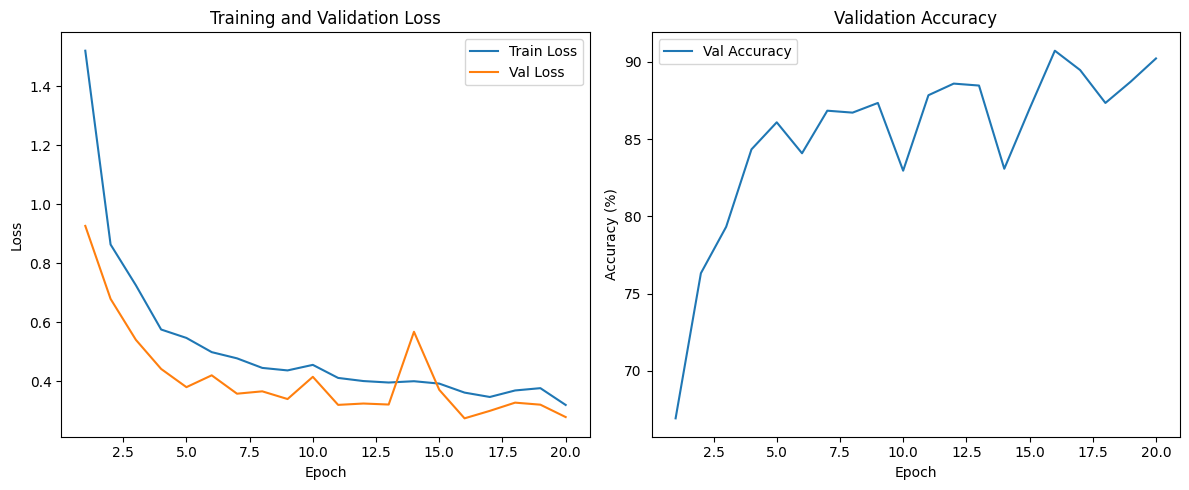

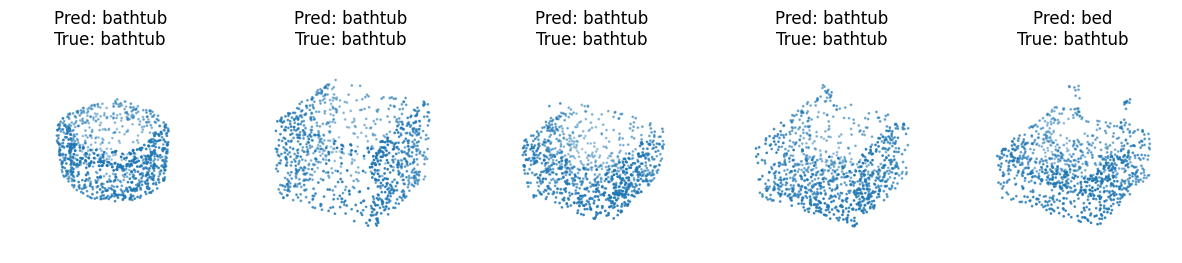

FOLD 1
--------------------------------
Epoch 1/5, Accuracy: 47.86%
Epoch 2/5, Accuracy: 60.48%
Epoch 3/5, Accuracy: 67.99%
Epoch 4/5, Accuracy: 71.22%
Epoch 5/5, Accuracy: 64.84%
Best Accuracy for fold 1: 71.22%

FOLD 2
--------------------------------
Epoch 1/5, Accuracy: 49.17%
Epoch 2/5, Accuracy: 66.99%
Epoch 3/5, Accuracy: 72.56%
Epoch 4/5, Accuracy: 80.75%
Epoch 5/5, Accuracy: 82.86%
Best Accuracy for fold 2: 82.86%

FOLD 3
--------------------------------
Epoch 1/5, Accuracy: 57.44%
Epoch 2/5, Accuracy: 70.98%
Epoch 3/5, Accuracy: 76.32%
Epoch 4/5, Accuracy: 76.84%
Epoch 5/5, Accuracy: 80.45%
Best Accuracy for fold 3: 80.45%

Average Validation Accuracy: 78.18% ± 5.01%
Test Accuracy: 84.47%


In [2]:
import os
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold
import trimesh
import kagglehub

# Lista klas ModelNet10
classes = ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Pobieranie danych via kagglehub (kompletne – nie zmieniaj)
def download_modelnet10():
    path = kagglehub.dataset_download("balraj98/modelnet10-princeton-3d-object-dataset")
    print("Path to dataset files:", path)
    
    data_dir = os.path.join(path, 'ModelNet10')
    if not os.path.exists(data_dir):
        data_dir = path
        print(f"Brak podkatalogu ModelNet10, używam bezpośredniego path: {data_dir}")
    
    class_dir_example = os.path.join(data_dir, classes[0])  # np. bathtub
    train_dir_example = os.path.join(class_dir_example, 'train')
    test_dir_example = os.path.join(class_dir_example, 'test')
    if os.path.exists(train_dir_example) and os.path.exists(test_dir_example):
        print("Struktura potwierdzona: ModelNet10/<class_name>/train/ i test/")
    else:
        print("Błąd: Brak katalogów train/ lub test/ w", class_dir_example)
        print("Zawartość katalogu datasetu:")
        !ls -la {data_dir}
        print("\nZawartość przykładowego katalogu klasy (bathtub):")
        !ls -la {class_dir_example}
        raise FileNotFoundError("Nie znaleziono oczekiwanej struktury <class_name>/train/test")
    
    return data_dir


# Preprocessing: Samplowanie punktów z plików .off i zapis do HDF5
def preprocess_modelnet10(num_points=1024):
    """Przetwarza pliki .off do chmur punktów i zapisuje do HDF5."""
    h5_path = '/content/data/modelnet10.h5'
    if os.path.exists(h5_path):
        print("Preprocessed dane już istnieją w", h5_path)
        return h5_path
    
    data_dir = download_modelnet10()
    os.makedirs('/content/data', exist_ok=True)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for split in ['train', 'test']:
        X_split, y_split = (X_train, y_train) if split == 'train' else (X_test, y_test)
        print(f"Przetwarzanie {split} set...")
        
        for class_name in classes:
            class_dir = os.path.join(data_dir, class_name, split)  # np. ModelNet10/bathtub/train/
            if not os.path.exists(class_dir):
                print(f"Uwaga: Katalog {class_dir} nie istnieje, pomijam klasę {class_name} w {split}")
                continue
            
            off_files = [f for f in os.listdir(class_dir) if f.endswith('.off')]
            print(f"  Klasa {class_name} ({split}): {len(off_files)} plików .off")
            
            for file in off_files:
                file_path = os.path.join(class_dir, file)
                try:
                    mesh = trimesh.load(file_path)
                    points, _ = trimesh.sample.sample_surface(mesh, num_points)
                    points = points - np.mean(points, axis=0)  # Centrowanie
                    points /= np.max(np.linalg.norm(points, axis=1)) + 1e-6  # Skalowanie
                    X_split.append(points)
                    y_split.append(class_to_idx[class_name])
                except Exception as e:
                    print(f"    Błąd przy pliku {file_path}: {e}")
        
        if split == 'train':
            X_train = np.array(X_train)
            y_train = np.array(y_split)
        else:
            X_test = np.array(X_split)
            y_test = np.array(y_split)
    
    # Zapisz do HDF5
    with h5py.File(h5_path, 'w') as hdf:
        hdf.create_dataset('X_train', data=X_train)
        hdf.create_dataset('y_train', data=y_train)
        hdf.create_dataset('X_test', data=X_test)
        hdf.create_dataset('y_test', data=y_test)
    
    print(f"Preprocessing zakończony. Kształty: Train {X_train.shape}, Test {X_test.shape}")
    return h5_path

# Przygotowanie danych (kompletne – nie zmieniaj)
class ModelNet10_Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)  # (N_samples, N_points, 3)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def load_data():
    h5_path = preprocess_modelnet10()
    
    with h5py.File(h5_path, 'r') as hdf:
        X_train = hdf['X_train'][:]
        y_train = hdf['y_train'][:]
        X_test = hdf['X_test'][:]
        y_test = hdf['y_test'][:]
    
    val_size = 0.2
    num_train = len(X_train)
    indices = list(range(num_train))
    np.random.shuffle(indices)
    split = int(np.floor(val_size * num_train))
    train_idx, val_idx = indices[split:], indices[:split]
    
    trainset = ModelNet10_Dataset(X_train[train_idx], y_train[train_idx])
    valset = ModelNet10_Dataset(X_train[val_idx], y_train[val_idx])
    testset = ModelNet10_Dataset(X_test, y_test)
    
    trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
    valloader = DataLoader(valset, batch_size=32, shuffle=False)
    testloader = DataLoader(testset, batch_size=32, shuffle=False)
    
    print(f"Dane załadowane: Train {len(trainset)}, Val {len(valset)}, Test {len(testset)}")
    return trainloader, valloader, testloader

# Definicja modelu PointNet
class TNet(nn.Module):
    """Transformation Network - generuje macierz transformacji (k x k)"""
    def __init__(self, k=3):
        super(TNet, self).__init__()
        self.k = k
        
        # Warstwy konwolucyjne (Conv1d) do ekstrakcji cech
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        
        # Batch normalization dla każdej warstwy konwolucyjnej
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        
        # Warstwy w pełni połączone (Linear) dla generacji macierzy transformacji
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k*k)
        
        # Dropout dla regularyzacji
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (batch, k, num_points)
        
        # Konwolucje z batch normalizacją i ReLU
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        # Global max pooling - wybierz maksymalną wartość dla każdego kanału
        x = torch.max(x, 2)[0]  # (batch, 1024)
        
        # Warstwy w pełni połączone z ReLU i dropoutem
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # (batch, k*k)
        
        # Dodaj macierz tożsamościową (inicjalizacja do transformacji identycznej)
        iden = torch.eye(self.k, device=x.device).view(1, self.k*self.k).repeat(x.size(0), 1)
        x = x + iden
        
        # Reshape do macierzy transformacji (batch, k, k)
        x = x.view(-1, self.k, self.k)
        return x

class PointNet(nn.Module):
    """PointNet - klasyfikacja chmur punktów"""
    def __init__(self, num_classes=10, num_points=1024):
        super(PointNet, self).__init__()
        self.num_classes = num_classes
        self.num_points = num_points
        
        # Transformation Networks
        self.tnet1 = TNet(k=3)   # Dla wejściowych koordinat (x, y, z)
        self.tnet2 = TNet(k=64)  # Dla cech 64D
        
        # Pierwsze warstwy konwolucyjne (na surowych punktach)
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        
        # Drugie warstwy konwolucyjne (feature transformation)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.bn3 = nn.BatchNorm1d(64)
        
        # Trzecie warstwy konwolucyjne (przed globalnym poolingiem)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.bn4 = nn.BatchNorm1d(128)
        
        self.conv5 = nn.Conv1d(128, 1024, 1)
        self.bn5 = nn.BatchNorm1d(1024)
        
        # Warstwy w pełni połączone dla klasyfikacji
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x: (batch, num_points, 3)
        
        # Transpose: (batch, 3, num_points)
        x = x.transpose(2, 1)
        
        # Pierwszy T-Net - transformacja dla wejściowych punktów
        t1 = self.tnet1(x)  # (batch, 3, 3)
        x = torch.bmm(x.transpose(2, 1), t1).transpose(2, 1)  # Zastosuj transformację
        
        # Konwolucje - ekstrakcja cech z punktów
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        # Drugi T-Net - transformacja dla cech
        t2 = self.tnet2(x)  # (batch, 64, 64)
        x = torch.bmm(x.transpose(2, 1), t2).transpose(2, 1)  # Zastosuj transformację
        
        # Dalsze konwolucje
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        
        # Global max pooling - agregacja cech ze wszystkich punktów
        x = torch.max(x, 2)[0]  # (batch, 1024)
        
        # Warstwy w pełni połączone dla klasyfikacji
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # (batch, num_classes)
        
        # Log-softmax dla CrossEntropyLoss
        return F.log_softmax(x, dim=1)

# Funkcja trenująca
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        # --- PĘTLA TRENINGOWA ---
        model.train()
        train_loss = 0.0
        
        for points, labels in trainloader:
            # Przeniesienie danych na urządzenie (GPU/CPU)
            points, labels = points.to(device), labels.to(device)
            
            # Wyzerowanie gradientów z poprzedniego kroku
            optimizer.zero_grad()
            
            # Forward pass: przewidywanie wyników
            outputs = model(points)
            loss = criterion(outputs, labels)
            
            # Backward pass: obliczenie gradientów
            loss.backward()
            
            # Optymalizacja: aktualizacja wag
            optimizer.step()
            
            train_loss += loss.item()
        
        # Obliczanie średniej straty treningowej
        epoch_train_loss = train_loss / len(trainloader)
        train_losses.append(epoch_train_loss)

        # --- PĘTLA WALIDACYJNA ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        # Wyłączenie obliczania gradientów dla oszczędności pamięci i czasu
        with torch.no_grad():
            for points, labels in valloader:
                points, labels = points.to(device), labels.to(device)
                
                outputs = model(points)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Obliczanie dokładności (Accuracy)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(valloader)
        val_accuracy = 100 * correct / total
        
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")
        
        # --- EARLY STOPPING ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()  # Zapisujemy najlepsze wagi
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs. Loading best model.")
                model.load_state_dict(best_model)
                break
    
    return train_losses, val_losses, val_accuracies

# Funkcje wizualizacyjne (kompletne – nie zmieniaj)
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, testloader, num_samples=5):
    device = next(model.parameters()).device
    model.eval()
    points, labels = next(iter(testloader))
    points, labels = points[:num_samples].to(device), labels[:num_samples].to(device)
    
    with torch.no_grad():
        outputs = model(points)
        _, predicted = torch.max(outputs, 1)
    
    points = points.cpu().numpy()
    
    fig = plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        ax = fig.add_subplot(1, num_samples, i+1, projection='3d')
        ax.scatter(points[i, :, 0], points[i, :, 1], points[i, :, 2], s=1)
        ax.set_title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        ax.axis('off')
    plt.show()

# Walidacja krzyżowa (uzupełnij brakujące fragmenty)
def cross_validation(k_folds=3, num_epochs=5):
    with h5py.File('/content/data/modelnet10.h5', 'r') as hdf:
        full_data = hdf['X_train'][:]
        full_labels = hdf['y_train'][:]
    
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pętla po foldach
    for fold, (train_ids, val_ids) in enumerate(kfold.split(full_data)):
        print(f'FOLD {fold + 1}')
        print('--------------------------------')

        # Tworzenie zbiorów treningowych i walidacyjnych
        train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
        val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)

        dataset = TensorDataset(
            torch.from_numpy(full_data).float(), 
            torch.from_numpy(full_labels).long()
        )

        # DataLoader'y
        train_loader = DataLoader(dataset, batch_size=32, sampler=train_subsampler)
        val_loader = DataLoader(dataset, batch_size=32, sampler=val_subsampler)

        # Inicjalizacja nowego modelu, kryterium i optymalizatora
        model = PointNet(num_classes=10).to(device)
        criterion = nn.NLLLoss() # Zgodnie z LogSoftmax w PointNet
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        best_fold_acc = 0.0

        # Pętla treningowa
        for epoch in range(num_epochs):
            model.train()
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            # Walidacja wewnątrz epoki
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs.data, 1)
                    total += targets.size(0)
                    correct += (predicted == targets).sum().item()
            
            epoch_acc = 100.0 * correct / total
            best_fold_acc = max(best_fold_acc, epoch_acc)
            print(f'Epoch {epoch+1}/{num_epochs}, Accuracy: {epoch_acc:.2f}%')

        results.append(best_fold_acc)
        print(f'Best Accuracy for fold {fold+1}: {best_fold_acc:.2f}%\n')

    print(f'Average Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# Główny kod (kompletny – nie zmieniaj)
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    trainloader, valloader, testloader = load_data()
    
    model = PointNet(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, patience=5)
    
    plot_metrics(train_losses, val_losses, val_accuracies)
    visualize_predictions(model, testloader)
    
    cross_validation(k_folds=3, num_epochs=5)
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for points, labels in testloader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Test Accuracy: {100 * correct / total:.2f}%")